# 花卉图像分类模型训练

## 任务：5种花卉分类（雏菊、蒲公英、玫瑰、向日葵、郁金香）
## 架构：ResNet50（迁移学习） + SimpleCNN（自定义CNN）
## 目标精度：≥85%


In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np, pandas as pd, os, sys, time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Auto-detect project root (walk up from cwd until backend/ + dataset/ found)
def get_project_root():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(current, 'backend')) and os.path.exists(os.path.join(current, 'dataset')):
            return current
        parent = os.path.dirname(current)
        if parent == current: break
        current = parent
    return os.getcwd()  # fallback
ROOT = get_project_root()
print(f'Project root: {ROOT}')

sys.path.insert(0, os.path.join(ROOT, 'backend', 'flower_model'))
from model import get_model, SimpleCNN

import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Project root: C:\Users\DOVE\python学习\大二下实训
Device: cuda


总样本数: 3670
类别: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
类别→索引: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


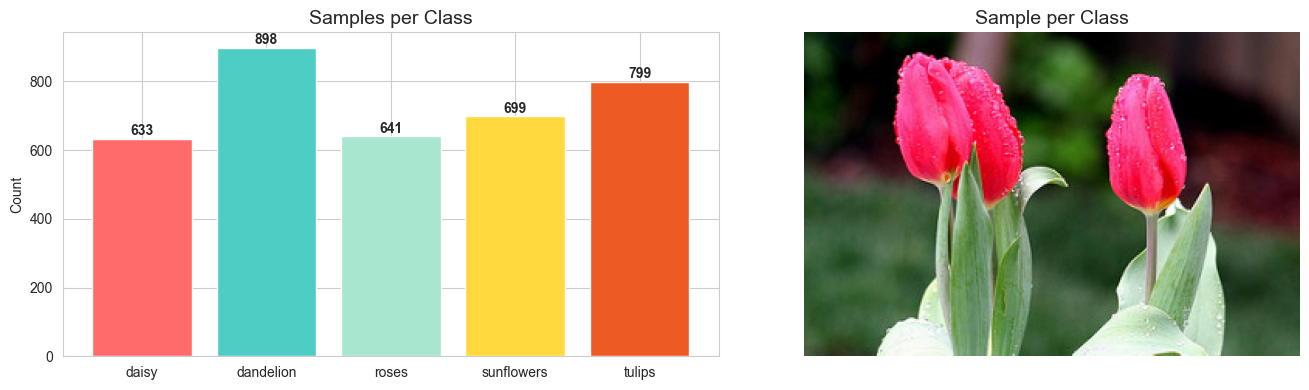

In [2]:
# ==================== 1. 数据探索 ====================
DATA_DIR = os.path.join(ROOT, 'dataset', 'flowers')
full_ds = datasets.ImageFolder(DATA_DIR)
print(f'总样本数: {len(full_ds)}')
print(f'类别: {full_ds.classes}')
print(f'类别→索引: {full_ds.class_to_idx}')

# 类别分布图
from collections import Counter
class_counts = Counter([label for _, label in full_ds])
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#FF6B6B','#4ECDC4','#A8E6CF','#FFD93D','#EE5A24']
ax[0].bar(full_ds.classes, [class_counts[i] for i in range(5)], color=colors, edgecolor='white')
ax[0].set_title('Samples per Class', fontsize=14)
ax[0].set_ylabel('Count')
for i, v in enumerate([class_counts[i] for i in range(5)]):
    ax[0].text(i, v+10, str(v), ha='center', fontweight='bold')

# 展示样本图片
indices = [np.where(np.array(full_ds.targets)==i)[0][0] for i in range(5)]
for i, (idx, cls) in enumerate(zip(indices, full_ds.classes)):
    img, _ = full_ds[idx]
    ax[1].imshow(img)
    ax[1].set_title(cls, fontsize=12)
    ax[1].axis('off')
ax[1].set_title('Sample per Class', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'flower_model', 'checkpoints', '01_data_overview.png'), dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# ==================== 2. 数据预处理与加载 ====================
class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform: x = self.transform(x)
        return x, y

train_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(20), transforms.RandomAffine(0, shear=10, scale=(0.8,1.2)),
    transforms.ColorJitter(0.2,0.2,0.2), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# 分层划分
from sklearn.model_selection import train_test_split
indices = list(range(len(full_ds)))
tr_idx, tmp = train_test_split(indices, test_size=0.3, random_state=42, stratify=full_ds.targets)
v_idx, te_idx = train_test_split(tmp, test_size=0.5, random_state=42, stratify=[full_ds.targets[i] for i in tmp])
print(f'Train: {len(tr_idx)} | Val: {len(v_idx)} | Test: {len(te_idx)}')

BATCH = 32
tr_loader = DataLoader(TransformedDataset(full_ds, tr_idx, train_tf), batch_size=BATCH, shuffle=True)
v_loader  = DataLoader(TransformedDataset(full_ds, v_idx, val_tf), batch_size=BATCH, shuffle=False)
te_loader  = DataLoader(TransformedDataset(full_ds, te_idx, val_tf), batch_size=BATCH, shuffle=False)


Train: 2569 | Val: 550 | Test: 551


In [4]:
# ==================== 3. 训练工具函数 ====================
def train_epoch(model, loader, crit, opt, dev):
    model.train(); total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad()
        loss = crit(model(x), y); loss.backward(); opt.step()
        total_loss += loss.item()
        correct += model(x).argmax(1).eq(y).sum().item()  # re-eval
        total += y.size(0)
    return total_loss/len(loader), 100.*correct/total

@torch.no_grad()
def evaluate(model, loader, crit, dev):
    model.eval(); total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(dev), y.to(dev)
        out = model(x)
        total_loss += crit(out, y).item()
        preds = out.argmax(1)
        correct += preds.eq(y).sum().item(); total += y.size(0)
        all_preds.extend(preds.cpu().numpy()); all_labels.extend(y.cpu().numpy())
    return total_loss/len(loader), 100.*correct/total, all_preds, all_labels

def train_full(model, name, tr_loader, v_loader, epochs, lr, patience, dev):
    model = model.to(dev); crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=5, factor=0.5)
    history = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
    best_acc, best_st, wait = 0, None, 0
    for ep in range(epochs):
        tl, ta = train_epoch(model, tr_loader, crit, opt, dev)
        vl, va, _, _ = evaluate(model, v_loader, crit, dev)
        sched.step(vl)
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl); history['val_acc'].append(va)
        if (ep+1)%5==0: print(f'[{name}] E{ep+1:3d} | TL={tl:.3f} TA={ta:.1f}% | VL={vl:.3f} VA={va:.1f}%')
        if va>best_acc: best_acc=va; best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else: wait+=1
        if wait>=patience: print(f'Early stop at {ep+1}'); break
    model.load_state_dict(best_st)
    return model, history, best_acc


In [5]:
# ==================== 4. 训练 ResNet50 ====================
print('=== Training ResNet50 (Transfer Learning) ===')
resnet = get_model('resnet50', 5)
resnet, hist_rn, acc_rn = train_full(resnet, 'ResNet50', tr_loader, v_loader, epochs=50, lr=0.001, patience=10, dev=DEVICE)

# 测试
_, te_acc_rn, rn_preds, rn_labels = evaluate(resnet, te_loader, nn.CrossEntropyLoss(), DEVICE)
print(f'ResNet50 Test Accuracy: {te_acc_rn:.2f}%')


=== Training ResNet50 (Transfer Learning) ===
[ResNet50] E  5 | TL=0.527 TA=84.5% | VL=0.550 VA=80.5%
[ResNet50] E 10 | TL=0.436 TA=87.7% | VL=0.464 VA=85.1%
[ResNet50] E 15 | TL=0.350 TA=90.9% | VL=0.340 VA=88.9%
[ResNet50] E 20 | TL=0.274 TA=94.0% | VL=0.385 VA=86.0%
[ResNet50] E 25 | TL=0.233 TA=94.8% | VL=0.606 VA=83.3%
Early stop at 28
ResNet50 Test Accuracy: 90.56%


In [6]:
# ==================== 5. 训练 SimpleCNN ====================
print('=== Training SimpleCNN ===')
cnn = SimpleCNN(5)
cnn, hist_cnn, acc_cnn = train_full(cnn, 'SimpleCNN', tr_loader, v_loader, epochs=80, lr=0.001, patience=15, dev=DEVICE)

_, te_acc_cnn, cnn_preds, cnn_labels = evaluate(cnn, te_loader, nn.CrossEntropyLoss(), DEVICE)
print(f'SimpleCNN Test Accuracy: {te_acc_cnn:.2f}%')


=== Training SimpleCNN ===
[SimpleCNN] E  5 | TL=0.960 TA=64.1% | VL=0.949 VA=64.7%
[SimpleCNN] E 10 | TL=0.854 TA=69.1% | VL=0.837 VA=69.5%
[SimpleCNN] E 15 | TL=0.770 TA=72.9% | VL=0.712 VA=75.6%
[SimpleCNN] E 20 | TL=0.700 TA=74.9% | VL=0.750 VA=73.1%
[SimpleCNN] E 25 | TL=0.706 TA=75.7% | VL=0.716 VA=76.0%
[SimpleCNN] E 30 | TL=0.658 TA=76.3% | VL=0.650 VA=75.6%
[SimpleCNN] E 35 | TL=0.626 TA=77.0% | VL=0.799 VA=79.1%
[SimpleCNN] E 40 | TL=0.588 TA=79.4% | VL=0.570 VA=81.6%
[SimpleCNN] E 45 | TL=0.530 TA=80.2% | VL=0.701 VA=80.7%
[SimpleCNN] E 50 | TL=0.560 TA=81.3% | VL=0.573 VA=81.3%
[SimpleCNN] E 55 | TL=0.519 TA=81.9% | VL=0.565 VA=83.3%
[SimpleCNN] E 60 | TL=0.415 TA=84.7% | VL=0.474 VA=85.8%
[SimpleCNN] E 65 | TL=0.389 TA=85.7% | VL=0.573 VA=85.3%
[SimpleCNN] E 70 | TL=0.348 TA=87.0% | VL=0.503 VA=84.9%
[SimpleCNN] E 75 | TL=0.326 TA=88.8% | VL=0.470 VA=87.1%
[SimpleCNN] E 80 | TL=0.300 TA=89.5% | VL=0.477 VA=87.3%
SimpleCNN Test Accuracy: 87.66%


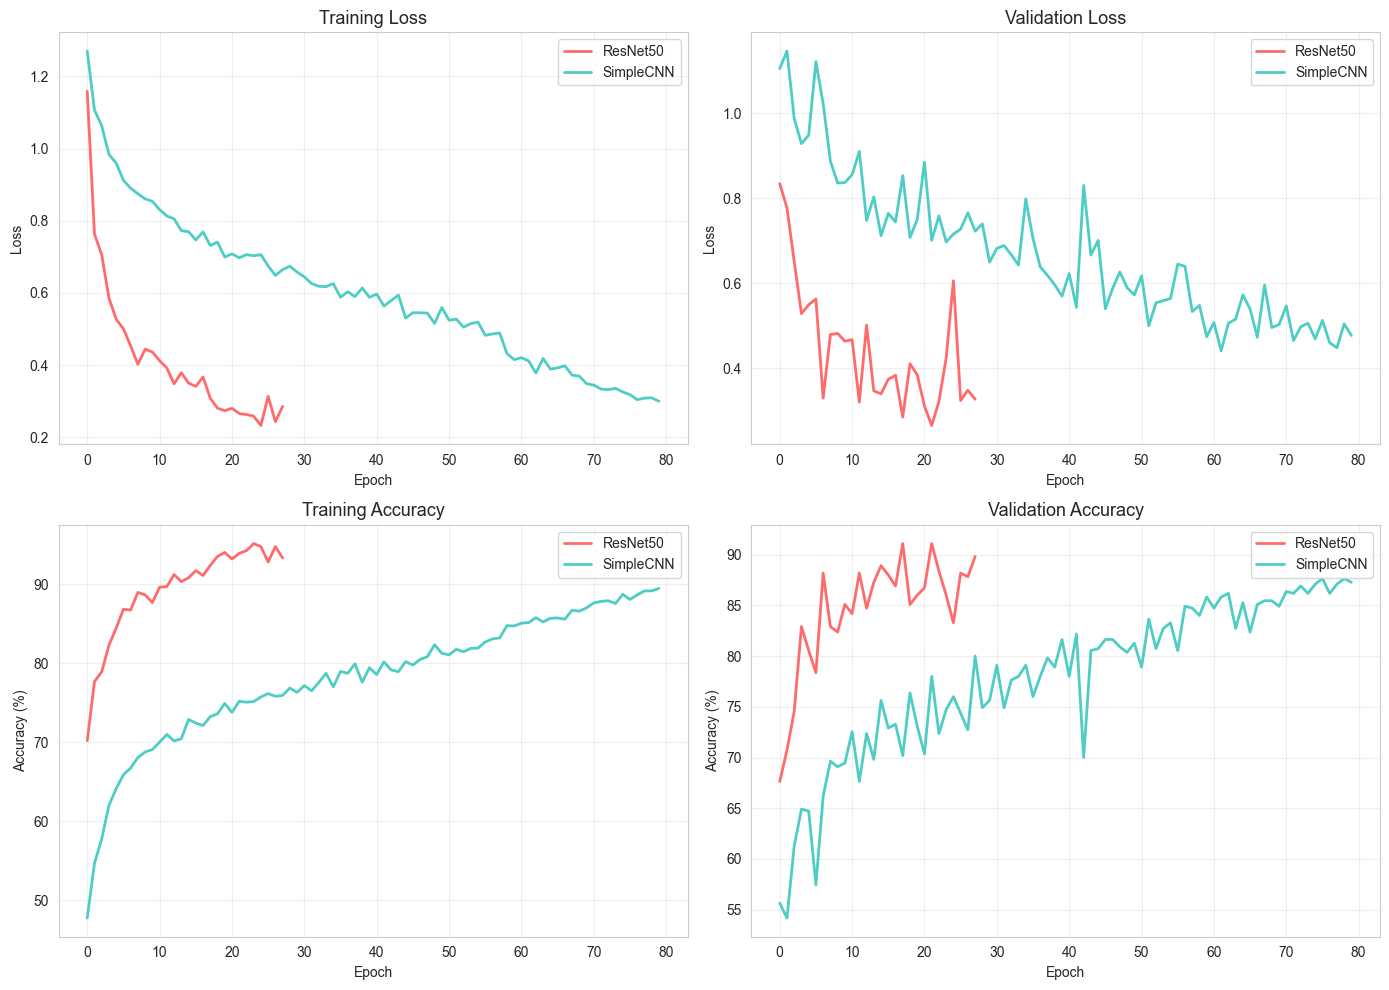

In [7]:
# ==================== 6. 训练曲线对比 ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key, title, ylab in [
    (axes[0,0], 'train_loss', 'Training Loss', 'Loss'),
    (axes[0,1], 'val_loss', 'Validation Loss', 'Loss'),
    (axes[1,0], 'train_acc', 'Training Accuracy', 'Accuracy (%)'),
    (axes[1,1], 'val_acc', 'Validation Accuracy', 'Accuracy (%)')]:
    ax.plot(hist_rn[key], label='ResNet50', color='#FF6B6B', linewidth=2)
    ax.plot(hist_cnn[key], label='SimpleCNN', color='#4ECDC4', linewidth=2)
    ax.set_title(title, fontsize=13); ax.set_xlabel('Epoch'); ax.set_ylabel(ylab)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'flower_model', 'checkpoints', '02_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


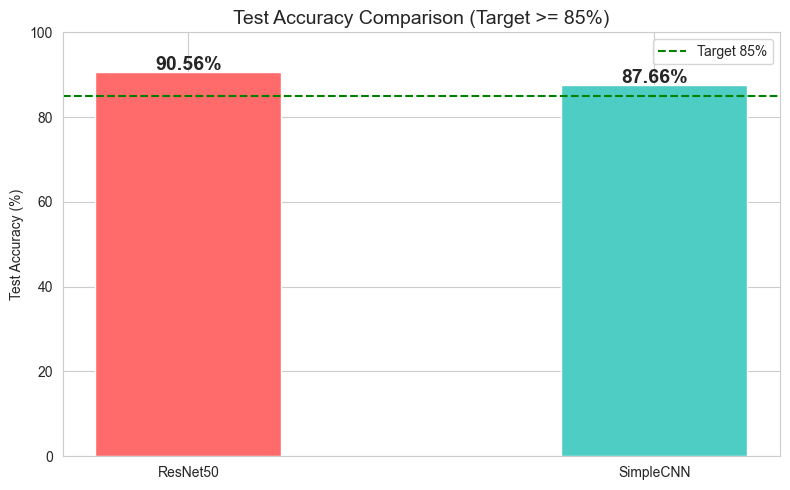

In [8]:
# ==================== 7. 测试精度对比柱状图 ====================
fig, ax = plt.subplots(figsize=(8, 5))
models = ['ResNet50', 'SimpleCNN']
accs = [te_acc_rn, te_acc_cnn]
bars = ax.bar(models, accs, color=['#FF6B6B','#4ECDC4'], edgecolor='white', width=0.4)
for b, v in zip(bars, accs): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel('Test Accuracy (%)'); ax.set_title('Test Accuracy Comparison (Target >= 85%)', fontsize=14)
ax.axhline(y=85, color='green', linestyle='--', label='Target 85%'); ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'flower_model', 'checkpoints', '03_accuracy_compare.png'), dpi=150, bbox_inches='tight')
plt.show()


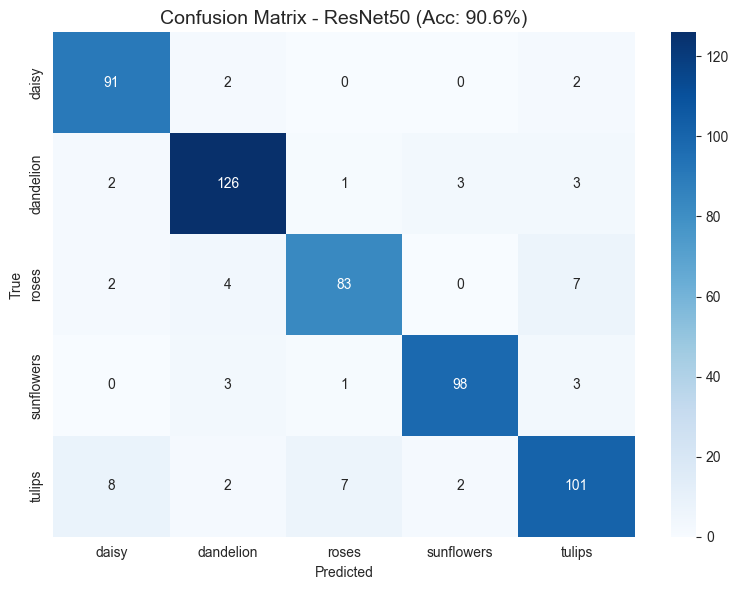


Classification Report:
              precision    recall  f1-score   support

       daisy       0.88      0.96      0.92        95
   dandelion       0.92      0.93      0.93       135
       roses       0.90      0.86      0.88        96
  sunflowers       0.95      0.93      0.94       105
      tulips       0.87      0.84      0.86       120

    accuracy                           0.91       551
   macro avg       0.91      0.91      0.91       551
weighted avg       0.91      0.91      0.91       551



In [9]:
# ==================== 8. 混淆矩阵 (最佳模型) ====================
best_model = resnet if te_acc_rn >= te_acc_cnn else cnn
best_preds = rn_preds if te_acc_rn >= te_acc_cnn else cnn_preds
best_labels = rn_labels if te_acc_rn >= te_acc_cnn else cnn_labels
best_name = 'ResNet50' if te_acc_rn >= te_acc_cnn else 'SimpleCNN'

cm = confusion_matrix(best_labels, best_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=full_ds.classes, yticklabels=full_ds.classes)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - {best_name} (Acc: {max(te_acc_rn, te_acc_cnn):.1f}%)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'flower_model', 'checkpoints', '04_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# 分类报告
print('\nClassification Report:')
print(classification_report(best_labels, best_preds, target_names=full_ds.classes))


In [10]:
# ==================== 9. 保存模型与结果 ====================
CHECKPOINT_DIR = os.path.join(ROOT, 'backend', 'flower_model', 'checkpoints')
torch.save({
    'resnet50_state_dict': {k:v.cpu().clone() for k,v in resnet.state_dict().items()},
    'simple_cnn_state_dict': {k:v.cpu().clone() for k,v in cnn.state_dict().items()},
    'class_names': full_ds.classes,
    'test_accuracy_resnet50': te_acc_rn,
    'test_accuracy_simple_cnn': te_acc_cnn,
}, os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
print(f'Model saved to {CHECKPOINT_DIR}')
print(f'ResNet50: {te_acc_rn:.2f}% | SimpleCNN: {te_acc_cnn:.2f}%')


Model saved to C:\Users\DOVE\python学习\大二下实训\backend\flower_model\checkpoints
ResNet50: 90.56% | SimpleCNN: 87.66%
